# Data Processing Performance Benchmark: Pandas vs Polars vs DuckDB
## Introduction
### Overview

This notebook benchmarks the performance of three popular data processing tools for common data science operations:

- **[Pandas](https://pandas.pydata.org/docs/)**: The traditional Python data analysis library, widely adopted but single-threaded
- **[Polars](https://docs.pola.rs/api/python/stable/reference/index.html)**: A modern DataFrame library implemented in Rust with parallel processing capabilities  
- **[DuckDB](https://duckdb.org/docs/stable/)**: An in-process SQL OLAP database optimized for analytical workloads

### Dataset

We use a synthetic e-commerce relational dataset available [here](https://www.kaggle.com/datasets/naelaqel/synthetic-e-commerce-relational-dataset) containing 5 tables:
- `customers`: 2,000,000 rows
- `orders`: 8,000,000 rows
- `order_items`: 20,000,000 rows
- `products`: 20,000 rows
- `product_reviews`: 4,000,000 rows

The Visual EDR
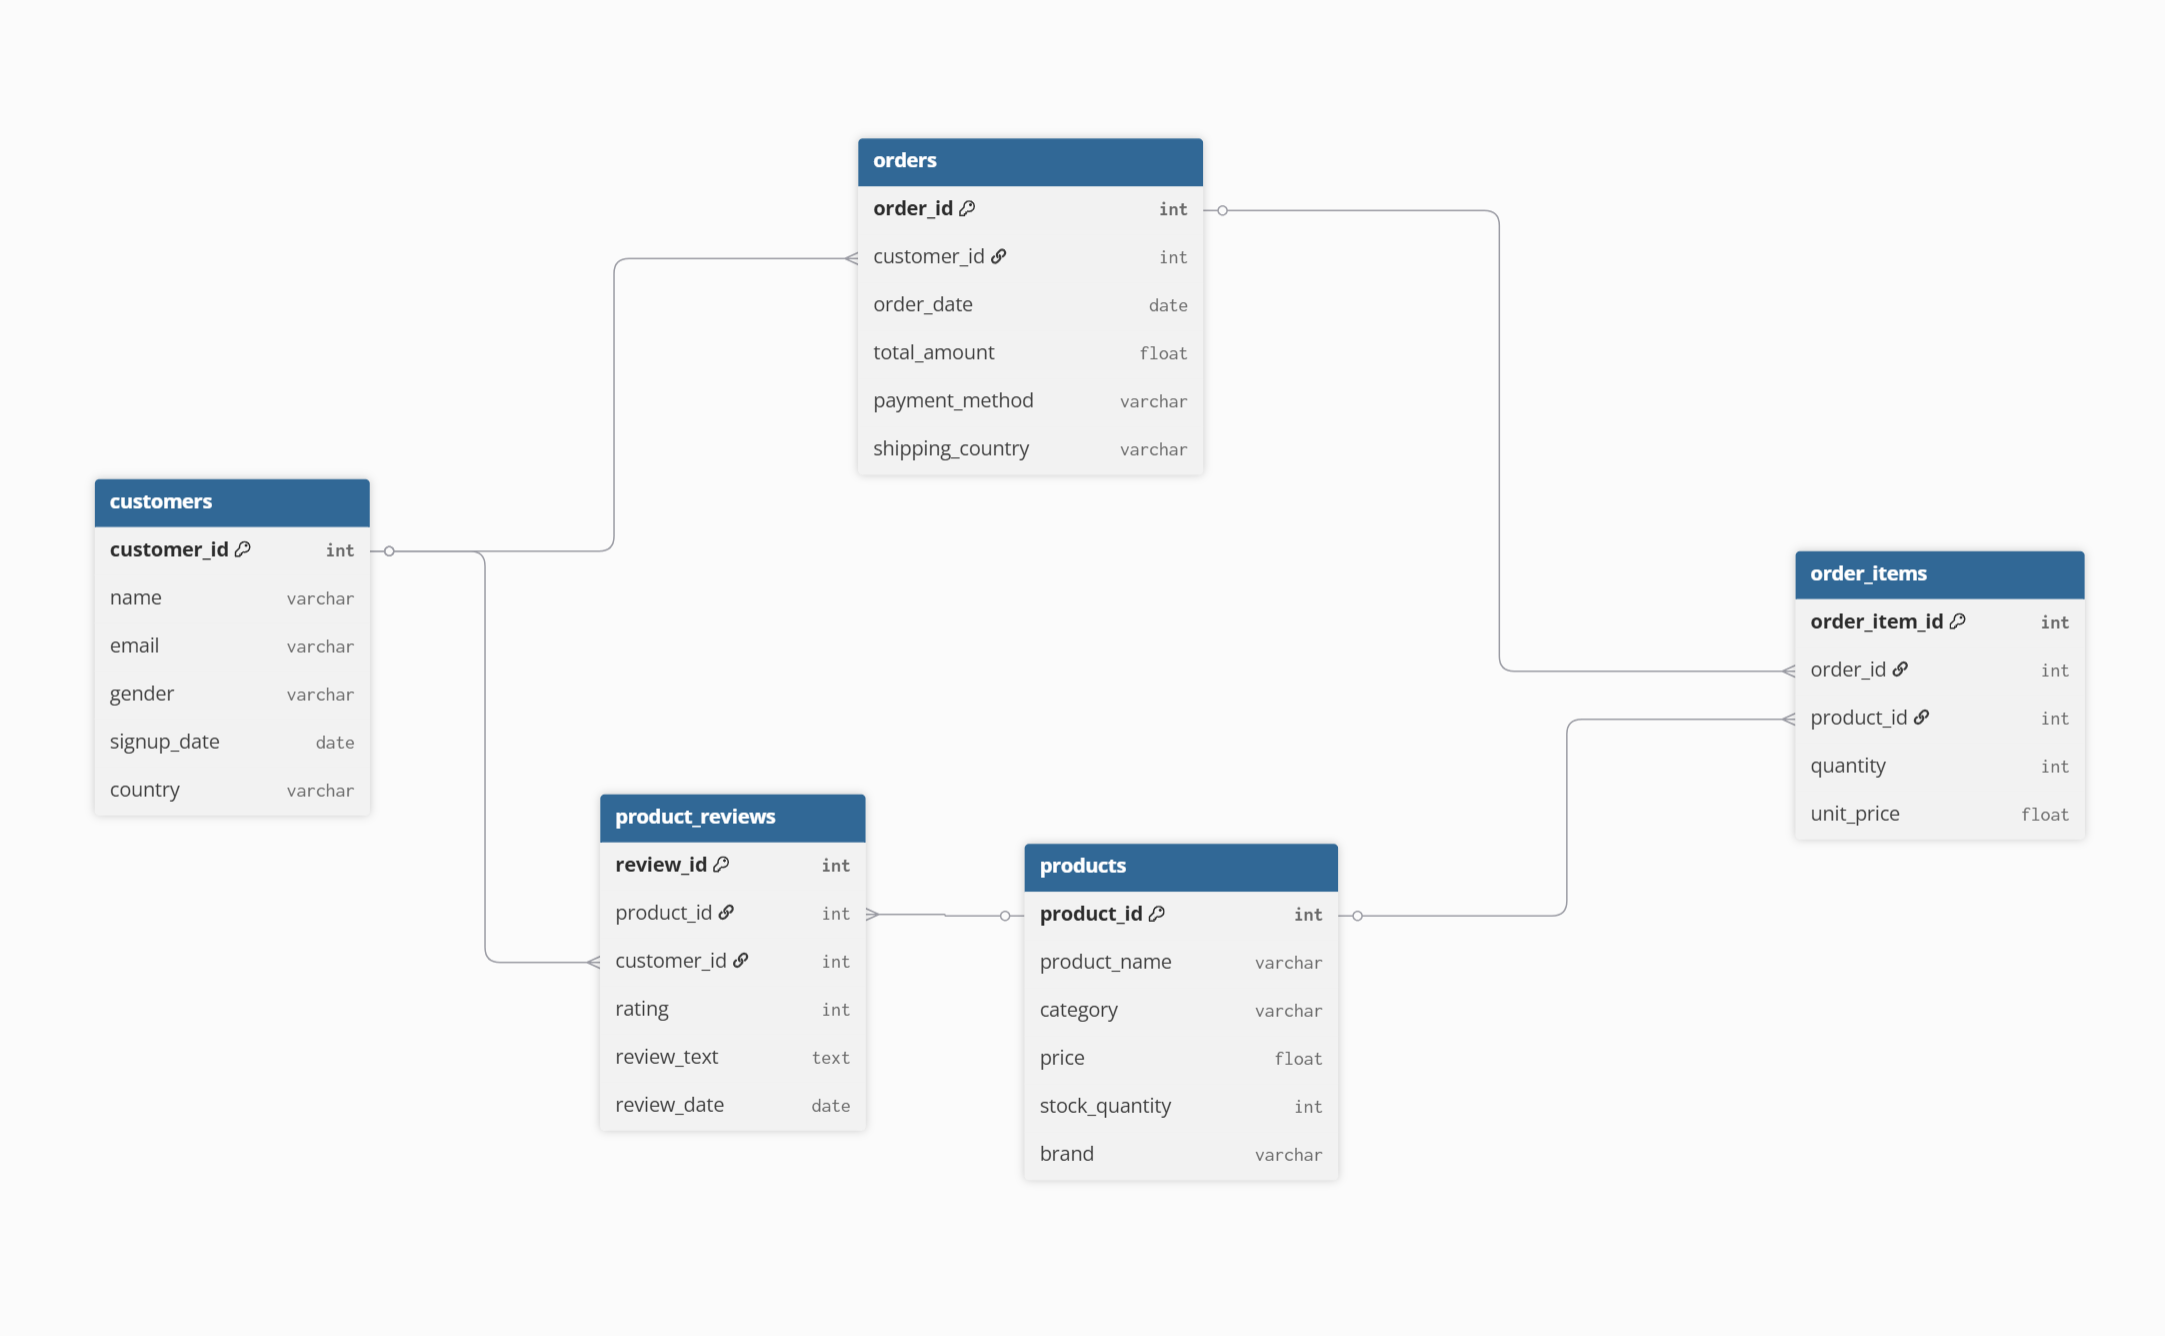


### Methodology of testing
- **Operations Tested**
    1. **File Loading**: Reading individual files into memory with default parameters, we will use these functions:
        - Pandas: [read_csv()](https://pandas.pydata.org/docs/reference/api/pandas.read_csv.html#pandas.read_csv) and [read_parquet()](https://pandas.pydata.org/docs/reference/api/pandas.read_parquet.html#pandas.read_parquet)
        - Polars: [read_csv()](https://docs.pola.rs/api/python/stable/reference/api/polars.read_csv.html) and [read_parquet()](https://docs.pola.rs/api/python/stable/reference/api/polars.read_parquet.html#polars.read_parquet)
        - DuckDB: we will read directly from the files' path, for reference we can also use [read_csv()](https://duckdb.org/docs/stable/data/csv/overview.html#csv-functions) and [read_parquet()](https://duckdb.org/docs/stable/data/parquet/overview) if we want to specify parameters.   
    2. **Join Operations**: Complex multi-table joins combining all 5 tables, we will left join `order_items -> orders -> customers -> products -> product_reviews` for all tools using:
        - Pandas: [merge()](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.merge.html#pandas.DataFrame.merge)
        - Polars: [join()](https://docs.pola.rs/api/python/stable/reference/dataframe/api/polars.DataFrame.join.html)
        - DuckDB: Normal SQL left joins   

- **File Formats**
    1. **CSV**: Text-based format, human-readable but larger file sizes
    2. **Parquet**: Columnar binary format, optimized for analytics

- **Key Performance Indicators (KPIs)**
    1. **Primary Metric**: Execution time in seconds using [time.perf_counter()](https://docs.python.org/3/library/time.html#time.perf_counter)
    2. **Derived Metrics**: Speedup ratios calculated as:
        - $\text{polars\_to\_pandas\_speedup\_ratio} = \dfrac{\text{pandas\_time}}{\text{polars\_time}}$
          
        - $\text{duckdb\_to\_pandas\_speedup\_ratio} = \dfrac{\text{pandas\_time}}{\text{duckdb\_time}}$
      
        - $\text{duckdb\_to\_polars\_speedup\_ratio} = \dfrac{\text{polars\_time}}{\text{duckdb\_time}}$

 > ***Values > 1.0 indicate the alternative tool is faster than the baseline***

- **Implementation Notes**
    - DuckDB approach: Reads files directly without loading into memory first
    - Pandas/Polars approach: Loads files into memory, then performs operations (and calculate the time for only joining (not loading))
    - For DuckDB and Polars, we measure only the initial data loading/parsing time without converting to DataFrames. Both tools have methods to convert their native objects to DataFrames, but we exclude this conversion step to measure pure I/O and parsing performance rather than materialization overhead. This approach provides a fairer comparison of each tool's core file reading capabilities. 

### Important Disclaimers

**Performance results may vary slightly between runs** due to:
- System resource availability
- Background processes
- Memory caching effects
- CPU thermal throttling

For production decisions, consider running multiple iterations and taking averages for more stable measurements.
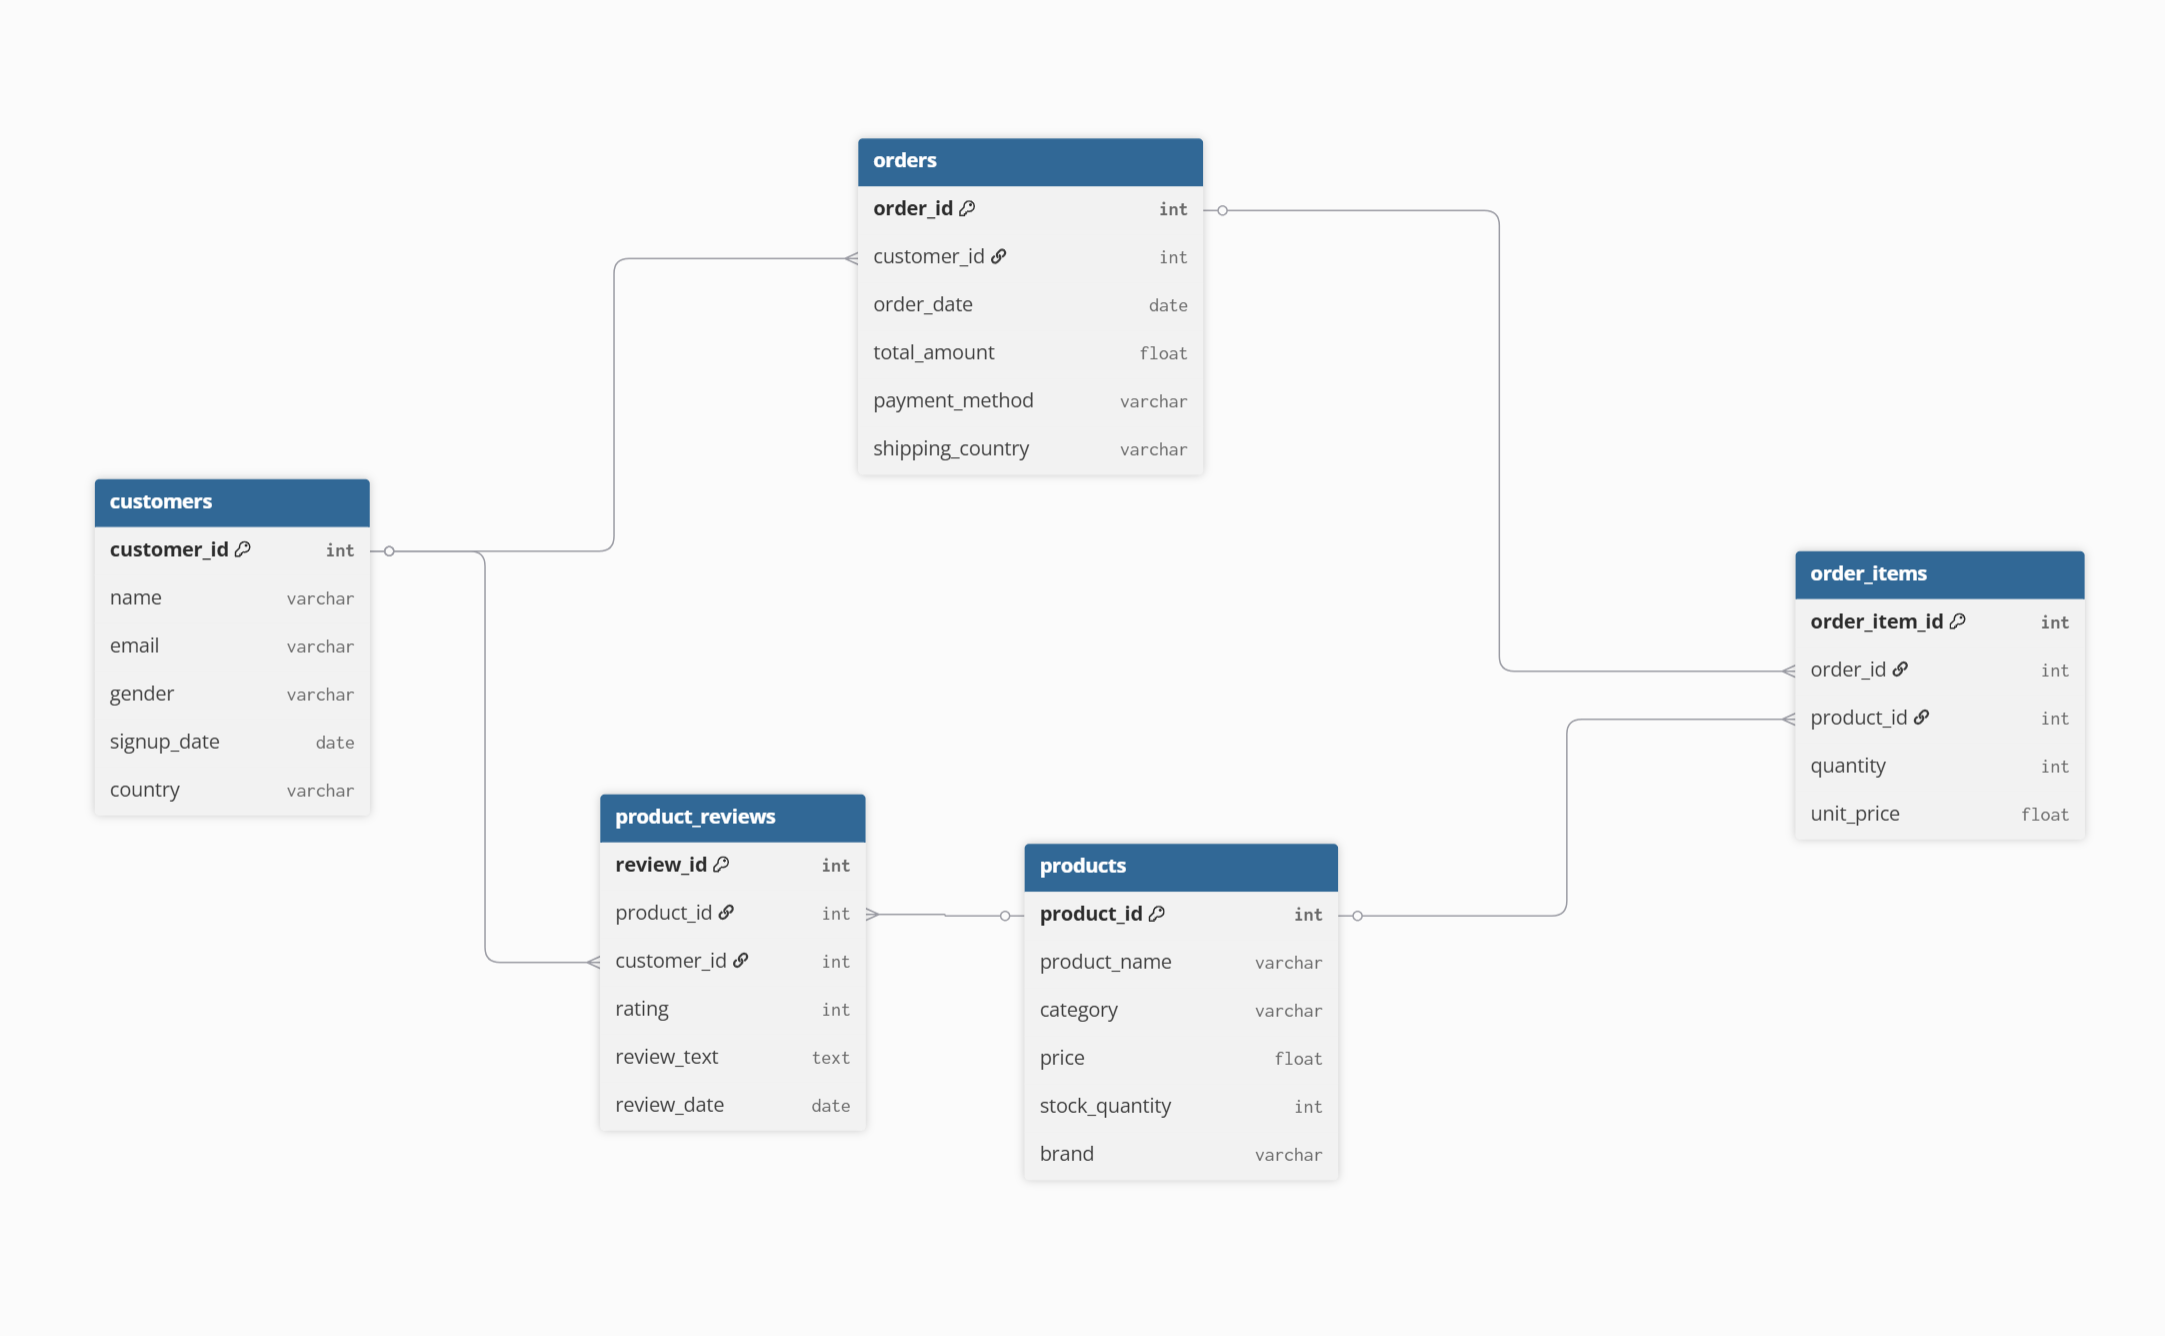

## Key Results Summary
### Loading Tables Performance
**DuckDB** is the Winner (specially for big datasets `>1M` rows):
- `CSV` format: **~2-200x** faster than `Pandas` and `Polars` 
- `Parquet` format: **~150-3,800x** faster than `Pandas` and `Polars` 
- For smaller datasets, `DuckDB` still leads but `Polars` may compete

> **Key insight: Performance gaps widen dramatically with dataset size**

### Joining Tables Performance
**DuckDB** is the Winner:
- `CSV` format: **~25-150x** faster than `Pandas` and `Polars`
- `Parquet` format: **~1,500-12,000x** faster than `Pandas` and `Polars`
- **Big advantage**: No memory loading required

> **Takeaway: DuckDB's direct file joins are game-changing**

### Recommended Workflow
Optimal Data Processing Strategy:
- Use `Parquet` format (massive performance boost)
- Load with `DuckDB`
- Perform joins and transformations in `DuckDB` SQL
- Then convert to DataFrame when needed:
    - `Pandas`: use [.df()](https://duckdb.org/docs/stable/guides/python/export_pandas)
    - `Polars`: use [.pl()](https://duckdb.org/docs/stable/guides/python/polars#duckdb-to-polars)

> **Bottom line: Start with DuckDB, convert only when necessary**

## Setup, Configurations and Defining functions
### Setup and Dependencies

First, let's install and import the required packages

In [ ]:
# Install required packages
!pip install -qq pandas
!pip install -qq duckdb
!pip install -qq polars

In [ ]:
# import modules
import pandas as pd
import polars as pl
import duckdb
import time

### Configuration and Setup

Define the test parameters and initialize our benchmarking environment

In [ ]:
# Define benchmark parameters
files = {'customers', 'orders', 'order_items', 'products', 'product_reviews'}  # Dataset files to test
tools = {'pandas', 'polars', 'duckdb'}    # Data processing tools to compare
input_formats = {'csv', 'parquet'}    # File formats to benchmark
path = '/kaggle/input/synthetic-e-commerce-relational-dataset'   # Path to dataset

# Initialize DuckDB connection for SQL-based operations
con = duckdb.connect()

### Sample of each tool output
Here we will just see an example for each tool's output, we will show the first 5 rows of the `products` table

In [ ]:
# pandas
pd.read_csv(f'{path}/csv/products.csv').head()

In [ ]:
# polars
pl.read_csv(f'{path}/csv/products.csv').head()

In [ ]:
# DuckDB
con.query(f"select * from '{path}/csv/products.csv' limit 5")

### Define Loading Functions

Create a dictionary of loading functions for each tool and file format combination

In [ ]:
# Define loading functions for each tool and file format combination
load_functions = {
    'csv': {
        'pandas': lambda file: pd.read_csv(file),
        'polars': lambda file: pl.read_csv(file),
        'duckdb': lambda file: con.query(f"select * from '{file}'")
        },
    'parquet': {
        'pandas': lambda file: pd.read_parquet(file),
        'polars': lambda file: pl.read_parquet(file),
        'duckdb': lambda file: con.query(f"select * from '{file}'")
        }
}

### Define Join Functions

Create join functions that perform the same multi-table join operation using each tool's syntax

In [ ]:
# Define join functions that perform the same multi-table join using each tool's syntax
join_functions = {
    # Pandas: uses merge() method with explicit join keys and suffixes (datasets will be inside dfs dictionary)
    'pandas': lambda dfs: dfs['order_items'] \
        .merge(dfs['orders'].merge(dfs['customers'], how='left', on='customer_id'), how='left', on='order_id') \
        .merge(dfs['products'], how='left', on='product_id') \
        .merge(dfs['product_reviews'], on=['product_id', 'customer_id'], how='left', suffixes=('', '_review')),

    # Polars: uses join() method with suffix parameter for column name conflicts (datasets will be inside dfs dictionary)
    'polars': lambda dfs: dfs['order_items'] \
        .join(dfs['orders'].join(dfs['customers'], how='left', on='customer_id'), how='left', on='order_id') \
        .join(dfs['products'], how='left', on='product_id') \
        .join(dfs['product_reviews'], on=['product_id', 'customer_id'], how='left', suffix='_review'),

    # DuckDB: uses SQL syntax for joins directly on files (so we wnat the input_format to read the correct file)
    'duckdb': lambda input_format: con.query(f'''
        select * from '{path}/{input_format}/order_items.{input_format}' 
        left join '{path}/{input_format}/orders.{input_format}' using(order_id) 
        left join '{path}/{input_format}/customers.{input_format}' using(customer_id) 
        left join '{path}/{input_format}/products.{input_format}' using(product_id) 
        left join '{path}/{input_format}/product_reviews.{input_format}' using(product_id, customer_id)
    ''')
} 

### Performance Profiling Utility

Define a helper function to measure execution time

In [ ]:
# make time_profile function to return time spent in function
def time_profile(func):
    """Measures execution time for a function using high-precision timer."""  
    start = time.perf_counter() # timer start
    func()                      # execute function
    end = time.perf_counter()   # timer end
    
    return end - start

-----
## File Loading Benchmark
Now let's benchmark the performance of loading operations across the three tools.

### Initialize Results Structure

Create a nested dictionary to store our benchmark results, the structure is `load_results[input_format][file][tool] = execution_time`

In [ ]:
# Structure: `load_results[input_format][file][tool] = execution_time`
load_results = {}

for input_format in input_formats:
    for tool in tools:
        for file in files:
            if input_format not in load_results:
                load_results[input_format] = {}
            if file not in load_results[input_format]:
                load_results[input_format][file] = {}
            if tool not in load_results[input_format][file]:
                load_results[input_format][file][tool] = {}

### Run Loading Benchmarks

Execute the benchmarks for each combination of file format, tool, and dataset

In [ ]:
# Execute file loading benchmarks for each combination
for input_format in input_formats:
    for tool in tools:
        for file in files:
            # Measure time to load each file with each tool
            load_results[input_format][file][tool] = time_profile(
                lambda: load_functions[input_format][tool](f'{path}/{input_format}/{file}.{input_format}'))


### Process and Display Results

Convert results to a DataFrame and calculate speedup ratios




In [ ]:
# Convert nested dictionary results to flat list for DataFrame creation
to_list = []

for input_format in load_results.keys():
    for file in load_results[input_format].keys():
        for tool in load_results[input_format][file].keys():
            to_list.append([input_format, file, tool, load_results[input_format][file][tool]])

# Create DataFrame from results
df = pd.DataFrame(to_list, columns=['input_format', 'file', 'tool', 'period_sec'])

# Pivot table with tools as columns for side-by-side comparison
df_summary = df.pivot_table(index=['input_format', 'file'], columns='tool', values='period_sec')[['pandas', 'polars', 'duckdb']]

# Calculate speedup ratios
df_summary['polars_to_pandas_speedup_ratio'] = round(df_summary['pandas'] / df_summary['polars'], 2)
df_summary['duckdb_to_pandas_speedup_ratio'] = round(df_summary['pandas'] / df_summary['duckdb'], 2)
df_summary['duckdb_to_polars_speedup_ratio'] = round(df_summary['polars'] / df_summary['duckdb'], 2)

# Display detailed results
df_summary

--------

## Join Operations Benchmark

Now let's benchmark the performance of join operations across the three tools

### Initialize Results Structure

Create a nested dictionary to store our benchmark results, the structure is `join_results[input_format][tool] = execution_time`

In [ ]:
# Structure: `join_results[input_format][tool] = execution_time`
join_results = {}

for input_format in input_formats:
    for tool in tools:
        if input_format not in join_results:
            join_results[input_format] = {}
        if tool not in join_results[input_format]:
            join_results[input_format][tool] = {}

### Run Join Benchmarks

Execute join benchmarks with different approaches for DuckDB (direct file access) vs others (in-memory operations) where we are loading the files first to `dfs` so the time calculations will be for the `join` only.

Also we re-write on `dfs` to save memory

In [ ]:
# Execute join benchmarks with different strategies for different tools
for input_format in input_formats:   
    for tool in tools:
        if tool != 'duckdb':
            # For pandas and polars: first load all files into memory, then perform joins
            dfs = {file: load_functions[input_format][tool](f'{path}/{input_format}/{file}.{input_format}') for file in files}
            join_results[input_format][tool] = time_profile(lambda: join_functions[tool](dfs))
        else:
            # For DuckDB: perform joins directly on files without loading into memory first
            join_results[input_format][tool] = time_profile(lambda: join_functions[tool](input_format))

# Clear memory
dfs = dict()

### Process Join Results

Convert join benchmark results to DataFrame and calculate speedup ratios:

In [ ]:
# Convert join results to DataFrame format
to_list_join = []

for input_format in join_results.keys():
    for tool in join_results[input_format].keys():
        to_list_join.append([input_format, tool, join_results[input_format][tool]])

# Create DataFrame from results
df_join = pd.DataFrame(to_list_join, columns=['input_format', 'tool', 'period_sec'])

# Pivot table with tools as columns for side-by-side comparison
df_join_summary = df_join.pivot_table(index=['input_format'], columns='tool', values='period_sec')[['pandas', 'polars', 'duckdb']]

# Calculate speedup ratios for join operations
df_join_summary['polars_to_pandas_speedup_ratio'] = round(df_join_summary['pandas'] / df_join_summary['polars'], 2)
df_join_summary['duckdb_to_pandas_speedup_ratio'] = round(df_join_summary['pandas'] / df_join_summary['duckdb'], 2)
df_join_summary['duckdb_to_polars_speedup_ratio'] = round(df_join_summary['polars'] / df_join_summary['duckdb'], 2)

# Display join benchmark results
df_join_summary